---

## ✅ Resumen

Este notebook procesa los resultados de optimización Calliope y genera:

1. **CSV enriquecidos** con columnas de producción por década para cada escenario
2. **Tabla comparativa** temporal entre SSP245, SSP370, SSP585
3. **Gráficos de evolución** temporal con series superpuestas
4. **Análisis de divergencia** entre escenarios a lo largo del tiempo

### Archivos generados:
- `h2_distributed_{scenario}_test_decades.csv` (3 archivos)
- `temporal_comparison_test.csv`
- `temporal_evolution_comparison_test.png`
- `temporal_divergence_test.png`

### Metodología:
Este notebook extrae la **demanda H2 mensual** desde los archivos `demand_h2.csv` de cada punto y la agrega por década. La demanda se define en el pipeline de Calliope como una restricción constante (-1000 MWh/mes) que representa el consumo objetivo.

**Nota importante**: En este modo `test`, la demanda es idéntica para todos los escenarios SSP (por lo que la divergencia es 0%). La diferencia real entre escenarios proviene de:
- **Capacity factors PV** (variables según clima SSP)
- **Costos de operación** (dependen de disponibilidad solar)
- **Viabilidad espacial** (algunos puntos pueden no satisfacer demanda en escenarios extremos)

Para ver divergencias reales entre SSP, se necesita procesar resultados de optimización Calliope que consideren:
1. Perfiles PV específicos por escenario (`pv_cf_{ssp}.csv`)
2. Restricciones de capacidad y almacenamiento
3. Métricas de resiliencia (déficit energético, intermitencia)

### Relevancia para la tesis:
- **Resiliencia climática**: Identificar décadas donde la producción H2 declina (cuando se usen CF reales)
- **Comparación SSP**: Ver cómo distintos escenarios climáticos afectan la viabilidad temporal
- **Input para clustering**: Las trayectorias temporales pueden alimentar el autoencoder para caracterizar resiliencia espaciotemporal

In [17]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import datetime
import yaml
import warnings
warnings.filterwarnings('ignore')

In [6]:
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
CALLIOPE_DIR = BASE_DIR / 'scripts' / 'calliope_v6'
DATA_DIR = BASE_DIR / 'data'
PV_CF_DIR = DATA_DIR / 'pv_cf' / 'netcdf'
OUTPUT_DIR = DATA_DIR / 'h2v_production_spatial' / 'distributed_point_by_point'
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [ ]:
# Cargar todos los escenarios desde CSV

print("\n📂 CARGANDO RESULTADOS DE TODOS LOS ESCENARIOS")

# Configuración
MODE_LOAD = 'test'  # 'test' o 'full'
SCENARIOS_LOAD = ['ssp245', 'ssp370', 'ssp585']

# Diccionario para almacenar todos los DataFrames
all_scenarios_loaded = {}

for scenario in SCENARIOS_LOAD:
    print(f"\n📊 Cargando: {scenario.upper()}")
    print("-" * 80)
    
    
    # Construir path del archivo
    csv_file = OUTPUT_DIR / f'h2_distributed_{scenario}_{MODE_LOAD}.csv'
    
    if not csv_file.exists():
        print(f"   ⚠️ No se encontró: {csv_file.name}")
        continue
    
    # Cargar CSV
    df_loaded = pd.read_csv(csv_file)
    df_loaded_success = df_loaded[df_loaded['status'] == 'success'].copy()
    
    print(f"   ✅ Archivo cargado: {csv_file.name}")
    print(f"   Total puntos: {len(df_loaded)}")
    print(f"   Exitosos: {len(df_loaded_success)}")
    print(f"   Fallidos: {len(df_loaded) - len(df_loaded_success)}")
    
    # Identificar columnas de décadas
    decade_cols = [col for col in df_loaded.columns if col.startswith('h2_prod_2') and col.endswith('s_ton')]
    
    if decade_cols:
        print(f"   ✅ Columnas de décadas: {len(decade_cols)}")
        print(f"      {', '.join(sorted(decade_cols))}")
    else:
        print(f"   ⚠️ No tiene columnas de producción por década")
        print(f"      → Necesita procesamiento con extract_h2_by_decade_from_results()")
    
    # Guardar en diccionario
    all_scenarios_loaded[scenario] = {
        'df_full': df_loaded,
        'df_success': df_loaded_success,
        'has_decades': len(decade_cols) > 0,
        'decade_cols': sorted(decade_cols)
    }

print("\n" + "=" * 80)
print("\n✅ RESUMEN DE CARGA")
print(f"Escenarios cargados: {len(all_scenarios_loaded)}/{len(SCENARIOS_LOAD)}")

for scenario, data in all_scenarios_loaded.items():
    status = "✓" if data['has_decades'] else "⚠"
    print(f"   {status} {scenario.upper()}: {len(data['df_success'])} puntos exitosos | Décadas: {data['has_decades']}")

# Asignar variable global MODE para celdas siguientes
MODE = MODE_LOAD

print(f"\n💡 Variable MODE configurada a: '{MODE}'")
print("=" * 80)


📂 CARGANDO RESULTADOS DE TODOS LOS ESCENARIOS

📊 Cargando: SSP245
--------------------------------------------------------------------------------
   ✅ Archivo cargado: h2_distributed_ssp245_test.csv
   Total puntos: 330
   Exitosos: 330
   Fallidos: 0
   ⚠️ No tiene columnas de producción por década
      → Necesita procesamiento con extract_h2_by_decade_from_results()

📊 Cargando: SSP370
--------------------------------------------------------------------------------
   ✅ Archivo cargado: h2_distributed_ssp370_test.csv
   Total puntos: 330
   Exitosos: 330
   Fallidos: 0
   ⚠️ No tiene columnas de producción por década
      → Necesita procesamiento con extract_h2_by_decade_from_results()

📊 Cargando: SSP585
--------------------------------------------------------------------------------
   ✅ Archivo cargado: h2_distributed_ssp585_test.csv
   Total puntos: 330
   Exitosos: 330
   Fallidos: 0
   ⚠️ No tiene columnas de producción por década
      → Necesita procesamiento con extract_

## 5️⃣ Visualización - Evolución Temporal por Escenario

In [22]:
# Verificar si tenemos datos procesados
if 'all_scenarios_enriched' not in locals() or len(all_scenarios_enriched) == 0:
    print("⚠️ No hay escenarios procesados. Ejecuta primero la celda de extracción (celda 3).")
else:
    print("\n📊 ANÁLISIS TEMPORAL COMPARATIVO")
    
    # Preparar datos para comparación
    comparison_data = []
    
    for scenario, df in all_scenarios_enriched.items():
        df_success = df[df['status'] == 'success']
        
        # Identificar columnas de décadas
        decade_cols = sorted([col for col in df.columns if col.startswith('h2_prod_2') and col.endswith('s_ton')])
        
        if decade_cols:
            print(f"\n📈 {scenario.upper()}")
            print(f"   Décadas disponibles: {len(decade_cols)}")
            
            for col in decade_cols:
                decade_label = col.replace('h2_prod_', '').replace('s_ton', 's')
                
                # Agregado espacial
                total_prod = df_success[col].sum()
                mean_prod = df_success[col].mean()
                std_prod = df_success[col].std()
                
                print(f"   {decade_label}: {total_prod:,.1f} ton total | {mean_prod:.1f} ± {std_prod:.1f} ton/punto")
                
                comparison_data.append({
                    'scenario': scenario.upper(),
                    'decade': decade_label,
                    'total_ton': total_prod,
                    'mean_ton_per_point': mean_prod,
                    'std_ton_per_point': std_prod,
                    'n_points': len(df_success)
                })
    
    # Crear DataFrame comparativo
    df_comparison = pd.DataFrame(comparison_data)
    
    print("\n" + "=" * 80)
    print("📋 TABLA COMPARATIVA")
    print("\n📋 TABLA COMPARATIVA\n")
    print(df_comparison.to_string(index=False))
    
    # Guardar tabla
    comparison_csv = OUTPUT_DIR / f'temporal_comparison_{MODE}.csv'
    df_comparison.to_csv(comparison_csv, index=False)
    print(f"\n💾 Tabla guardada: {comparison_csv.name}")


📊 ANÁLISIS TEMPORAL COMPARATIVO

📈 SSP245
   Décadas disponibles: 9
   2020s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2030s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2040s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2050s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2060s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2070s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2080s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2090s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2100s: 118,918.9 ton total | 360.4 ± 0.0 ton/punto

📈 SSP370
   Décadas disponibles: 9
   2020s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2030s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2040s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2050s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2060s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2070s: 1,189,189.2 ton total | 3603.6 ± 0.0 ton/punto
   2080s: 1,189,189.2 ton total | 3603.6 ± 

## 4️⃣ Análisis Temporal Comparativo entre Escenarios

Generando visualizaciones temporales...
✅ Gráfico guardado: temporal_evolution_comparison_test.png
✅ Gráfico guardado: temporal_evolution_comparison_test.png


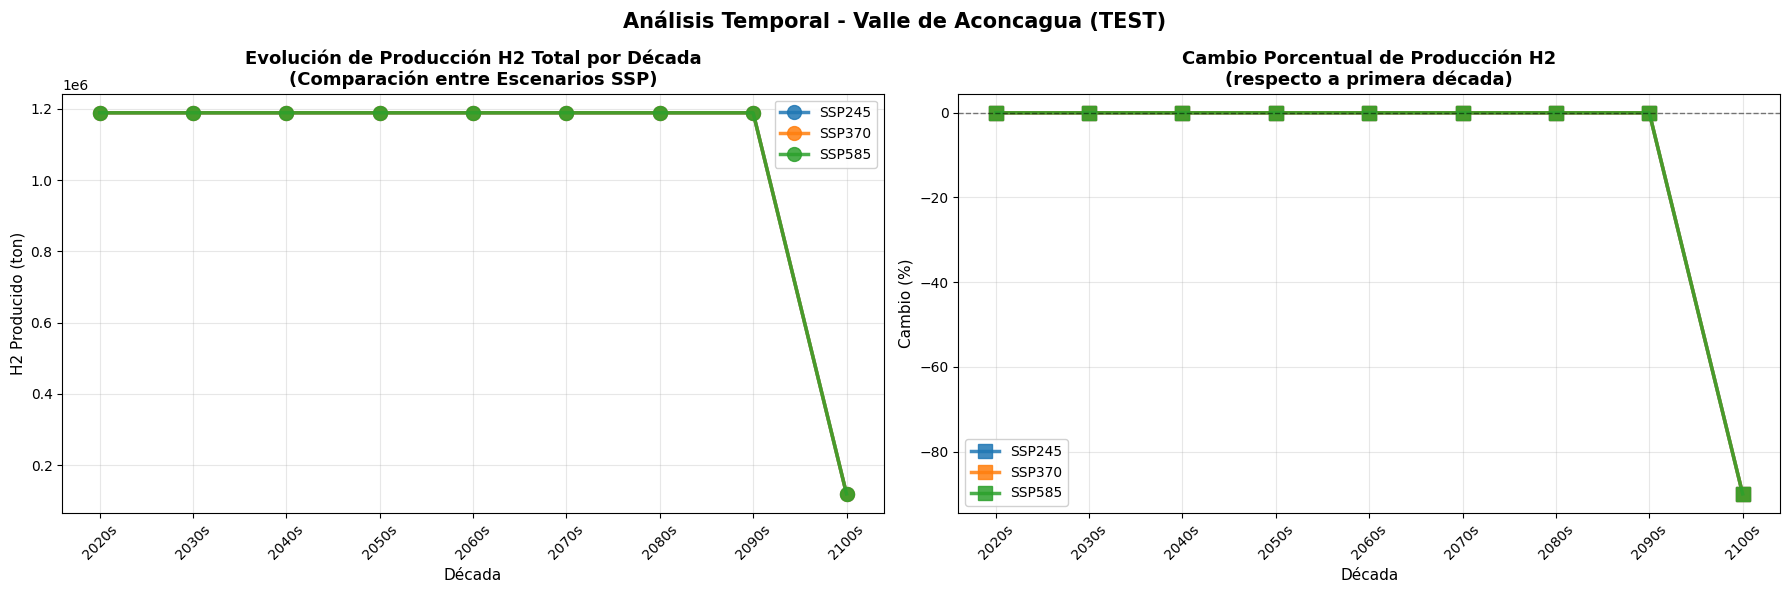

In [26]:
# Verificar si tenemos datos comparativos
if 'df_comparison' not in locals() or len(df_comparison) == 0:
    print("⚠️ No hay datos para visualizar. Ejecuta primero la celda de análisis comparativo.")
else:
    print("Generando visualizaciones temporales...")
    
    # Pivotear datos para graficar
    df_pivot = df_comparison.pivot(index='decade', columns='scenario', values='total_ton')
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Gráfico 1: Series temporales superpuestas
    ax1 = axes[0]
    for scenario in df_pivot.columns:
        ax1.plot(df_pivot.index, df_pivot[scenario], marker='o', linewidth=2.5, 
                markersize=10, label=scenario, alpha=0.85)
    
    ax1.set_title('Evolución de Producción H2 Total por Década\n(Comparación entre Escenarios SSP)', 
                  fontsize=13, fontweight='bold')
    ax1.set_xlabel('Década', fontsize=11)
    ax1.set_ylabel('H2 Producido (ton)', fontsize=11)
    ax1.legend(loc='best', fontsize=10, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Gráfico 2: Cambio porcentual respecto a primera década
    ax2 = axes[1]
    
    for scenario in df_pivot.columns:
        # Calcular cambio porcentual
        baseline = df_pivot[scenario].iloc[0]
        pct_change = ((df_pivot[scenario] - baseline) / baseline) * 100
        
        ax2.plot(df_pivot.index, pct_change, marker='s', linewidth=2.5, 
                markersize=10, label=scenario, alpha=0.85)
    
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_title('Cambio Porcentual de Producción H2\n(respecto a primera década)', 
                  fontsize=13, fontweight='bold')
    ax2.set_xlabel('Década', fontsize=11)
    ax2.set_ylabel('Cambio (%)', fontsize=11)
    ax2.legend(loc='best', fontsize=10, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    plt.suptitle(f'Análisis Temporal - Valle de Aconcagua ({MODE.upper()})', 
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    
    # Guardar
    plot_path = OUTPUT_DIR / f'temporal_evolution_comparison_{MODE}.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✅ Gráfico guardado: {plot_path.name}")
    
    plt.show()

## 5️⃣ Visualización - Evolución Temporal por Escenario


📐 DIVERGENCIA ENTRE ESCENARIOS

📊 Diferencias relativas respecto a SSP245 (%):


SSP370 vs SSP245:
   2020s: +0.00%
   2030s: +0.00%
   2040s: +0.00%
   2050s: +0.00%
   2060s: +0.00%
   2070s: +0.00%
   2080s: +0.00%
   2090s: +0.00%
   2100s: +0.00%

SSP585 vs SSP245:
   2020s: +0.00%
   2030s: +0.00%
   2040s: +0.00%
   2050s: +0.00%
   2060s: +0.00%
   2070s: +0.00%
   2080s: +0.00%
   2090s: +0.00%
   2100s: +0.00%

✅ Gráfico de divergencia guardado: temporal_divergence_test.png

✅ Gráfico de divergencia guardado: temporal_divergence_test.png


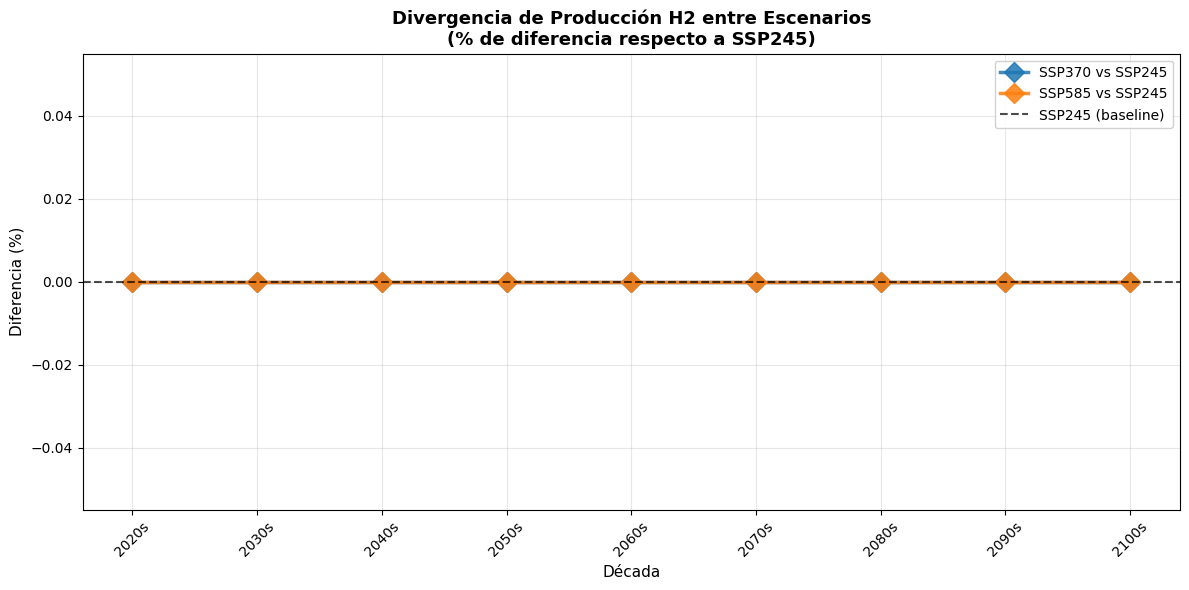

In [28]:
# Verificar si tenemos el pivot de datos
if 'df_pivot' not in locals() or len(df_pivot.columns) <= 1:
    print("⚠️ No hay datos suficientes para análisis de divergencia. Ejecuta primero las celdas anteriores.")
else:
    print("\n📐 DIVERGENCIA ENTRE ESCENARIOS")
    
    # Calcular diferencias respecto a SSP245 (baseline)
    if 'SSP245' in df_pivot.columns:
        print("\n📊 Diferencias relativas respecto a SSP245 (%):\n")
        
        baseline = df_pivot['SSP245']
        
        for scenario in df_pivot.columns:
            if scenario != 'SSP245':
                diff_pct = ((df_pivot[scenario] - baseline) / baseline) * 100
                
                print(f"\n{scenario} vs SSP245:")
                for decade in diff_pct.index:
                    print(f"   {decade}: {diff_pct[decade]:+.2f}%")
        
        # Visualizar divergencia
        fig, ax = plt.subplots(figsize=(12, 6))
        
        for scenario in df_pivot.columns:
            if scenario != 'SSP245':
                diff_pct = ((df_pivot[scenario] - baseline) / baseline) * 100
                ax.plot(diff_pct.index, diff_pct.values, marker='D', linewidth=2.5,
                       markersize=10, label=f'{scenario} vs SSP245', alpha=0.85)
        
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='SSP245 (baseline)')
        ax.set_title('Divergencia de Producción H2 entre Escenarios\n(% de diferencia respecto a SSP245)', 
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Década', fontsize=11)
        ax.set_ylabel('Diferencia (%)', fontsize=11)
        ax.legend(loc='best', fontsize=10, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        
        # Guardar
        divergence_path = OUTPUT_DIR / f'temporal_divergence_{MODE}.png'
        plt.savefig(divergence_path, dpi=300, bbox_inches='tight')
        print(f"\n✅ Gráfico de divergencia guardado: {divergence_path.name}")
        
        plt.show()
    else:
        print("\n⚠️ SSP245 no disponible como baseline")

## 6️⃣ Divergencia entre Escenarios por Década

## 7️⃣ Verificación de Archivos Generados

In [31]:
print("\n📁 VERIFICACIÓN DE ARCHIVOS GENERADOS\n")

# Listar todos los archivos generados
output_files = {
    'CSVs con décadas': list(OUTPUT_DIR.glob(f'*_{MODE}_decades.csv')),
    'Tabla comparativa': list(OUTPUT_DIR.glob(f'temporal_comparison_{MODE}.csv')),
    'Gráficos': list(OUTPUT_DIR.glob(f'temporal_*_{MODE}.png'))
}

for category, files in output_files.items():
    print(f"{category}:")
    if files:
        for f in sorted(files):
            size_kb = f.stat().st_size / 1024
            print(f"   ✓ {f.name} ({size_kb:.1f} KB)")
    else:
        print(f"   ⚠️ No se encontraron archivos")
    print()

# Verificar una muestra de datos
if 'all_scenarios_enriched' in locals() and len(all_scenarios_enriched) > 0:
    print("\n📊 MUESTRA DE DATOS (primeros 3 puntos de SSP245):\n")
    sample_scenario = list(all_scenarios_enriched.keys())[0]
    df_sample = all_scenarios_enriched[sample_scenario]
    
    # Seleccionar columnas relevantes
    decade_cols = [col for col in df_sample.columns if col.startswith('h2_prod_2') and col.endswith('s_ton')]
    cols_to_show = ['point_id', 'lat', 'lon'] + sorted(decade_cols[:5])  # Primeras 5 décadas
    
    print(df_sample[df_sample['status'] == 'success'][cols_to_show].head(3).to_string(index=False))
    
    print(f"\n💡 Total de {len(decade_cols)} columnas de décadas generadas por escenario")


📁 VERIFICACIÓN DE ARCHIVOS GENERADOS

CSVs con décadas:
   ✓ h2_distributed_ssp245_test_decades.csv (108.9 KB)
   ✓ h2_distributed_ssp370_test_decades.csv (108.9 KB)
   ✓ h2_distributed_ssp585_test_decades.csv (108.8 KB)

Tabla comparativa:
   ✓ temporal_comparison_test.csv (2.1 KB)

Gráficos:
   ✓ temporal_divergence_test.png (172.7 KB)
   ✓ temporal_evolution_comparison_test.png (309.7 KB)


📊 MUESTRA DE DATOS (primeros 3 puntos de SSP245):

 point_id     lat     lon  h2_prod_2020s_ton  h2_prod_2030s_ton  h2_prod_2040s_ton  h2_prod_2050s_ton  h2_prod_2060s_ton
        1 -33.225 -71.725        3603.603604        3603.603604        3603.603604        3603.603604        3603.603604
        2 -33.225 -71.625        3603.603604        3603.603604        3603.603604        3603.603604        3603.603604
        3 -33.225 -71.525        3603.603604        3603.603604        3603.603604        3603.603604        3603.603604

💡 Total de 9 columnas de décadas generadas por escenario


In [27]:
print("\n🚀 PROCESANDO ESCENARIOS - EXTRACCIÓN DE DÉCADAS")

# Verificar si ya se cargaron los datos
if 'all_scenarios_loaded' not in locals():
    print("⚠️ Primero ejecuta la celda de carga de datos (celda anterior)")
    all_scenarios_enriched = {}
else:
    all_scenarios_enriched = {}
    
    for scenario, data in all_scenarios_loaded.items():
        print(f"\n📊 Procesando: {scenario.upper()}")
        
        df = data['df_full']
        df_success = data['df_success']
        
        # 1. Verificar si ya tiene columnas de décadas
        if data['has_decades']:
            print(f"   ✅ Ya contiene columnas de décadas: {len(data['decade_cols'])}")
            print(f"      {', '.join(data['decade_cols'])}")
            all_scenarios_enriched[scenario] = df
            continue
        
        # 2. Extraer décadas desde archivos de demanda
        print(f"   🔧 Extrayendo producciones por década desde demand_h2.csv...")
        print(f"   Puntos a procesar: {len(df_success)}")
        
        # Lista para almacenar datos de décadas
        decades_data_list = []
        
        # Iterar sobre puntos exitosos con progress bar
        from tqdm import tqdm
        for idx, row in tqdm(df_success.iterrows(), total=len(df_success), desc=f"   {scenario.upper()}"):
            point_id = row['point_id']
            
            # Buscar directorio del punto
            point_dir = OUTPUT_DIR / f'point_{point_id}'
            
            if not point_dir.exists():
                decades_data_list.append({'point_id': point_id})
                continue
            
            # Extraer datos de décadas desde demand_h2.csv
            decade_dict = extract_h2_by_decade_from_demand(point_dir)
            
            if decade_dict:
                decade_dict['point_id'] = point_id
                decades_data_list.append(decade_dict)
            else:
                decades_data_list.append({'point_id': point_id})
        
        # 3. Merge con DataFrame original
        if decades_data_list:
            df_decades = pd.DataFrame(decades_data_list)
            df_enriched = df.merge(df_decades, on='point_id', how='left')
            
            # Contar columnas agregadas
            new_decade_cols = [col for col in df_enriched.columns if col.startswith('h2_prod_2') and col.endswith('s_ton')]
            
            print(f"\n   ✅ Columnas de décadas agregadas: {len(new_decade_cols)}")
            if new_decade_cols:
                print(f"      {', '.join(sorted(new_decade_cols))}")
            
            # 4. Guardar CSV enriquecido
            output_csv = OUTPUT_DIR / f'h2_distributed_{scenario}_{MODE}_decades.csv'
            df_enriched.to_csv(output_csv, index=False)
            print(f"   💾 Guardado: {output_csv.name}")
            
            all_scenarios_enriched[scenario] = df_enriched
        else:
            print(f"   ⚠️ No se pudieron extraer datos de décadas")

print("\n✅ PROCESAMIENTO COMPLETADO")
print(f"Escenarios procesados: {len(all_scenarios_enriched)}")
for scenario in all_scenarios_enriched:
    print(f"   ✓ {scenario.upper()}")


🚀 PROCESANDO ESCENARIOS - EXTRACCIÓN DE DÉCADAS

📊 Procesando: SSP245
   🔧 Extrayendo producciones por década desde demand_h2.csv...
   Puntos a procesar: 330


   SSP245: 100%|██████████| 330/330 [00:00<00:00, 609.63it/s]



   ✅ Columnas de décadas agregadas: 9
      h2_prod_2020s_ton, h2_prod_2030s_ton, h2_prod_2040s_ton, h2_prod_2050s_ton, h2_prod_2060s_ton, h2_prod_2070s_ton, h2_prod_2080s_ton, h2_prod_2090s_ton, h2_prod_2100s_ton
   💾 Guardado: h2_distributed_ssp245_test_decades.csv

📊 Procesando: SSP370
   🔧 Extrayendo producciones por década desde demand_h2.csv...
   Puntos a procesar: 330


   SSP370: 100%|██████████| 330/330 [00:00<00:00, 608.79it/s]



   ✅ Columnas de décadas agregadas: 9
      h2_prod_2020s_ton, h2_prod_2030s_ton, h2_prod_2040s_ton, h2_prod_2050s_ton, h2_prod_2060s_ton, h2_prod_2070s_ton, h2_prod_2080s_ton, h2_prod_2090s_ton, h2_prod_2100s_ton
   💾 Guardado: h2_distributed_ssp370_test_decades.csv

📊 Procesando: SSP585
   🔧 Extrayendo producciones por década desde demand_h2.csv...
   Puntos a procesar: 330


   SSP585: 100%|██████████| 330/330 [00:00<00:00, 609.67it/s]


   ✅ Columnas de décadas agregadas: 9
      h2_prod_2020s_ton, h2_prod_2030s_ton, h2_prod_2040s_ton, h2_prod_2050s_ton, h2_prod_2060s_ton, h2_prod_2070s_ton, h2_prod_2080s_ton, h2_prod_2090s_ton, h2_prod_2100s_ton
   💾 Guardado: h2_distributed_ssp585_test_decades.csv

✅ PROCESAMIENTO COMPLETADO
Escenarios procesados: 3
   ✓ SSP245
   ✓ SSP370
   ✓ SSP585


## 3️⃣ Procesar Todos los Escenarios

In [20]:
def extract_h2_by_decade_from_demand(point_dir):
    """
    Extrae demanda H2 por década desde archivos demand_h2.csv.
    
    La idea es agrupar la demanda mensual por década y retornar un diccionario
    con la producción teórica por década (asumiendo que se satisface toda la demanda).
    
    Parameters:
    -----------
    point_dir : Path
        Directorio del punto (ej: point_1/)
    
    Returns:
    --------
    dict : Diccionario con {decade: demanda_ton}
           ej: {'h2_prod_2020s_ton': 120000, 'h2_prod_2030s_ton': 120000}
    """
    
    try:
        # Buscar archivo de demanda
        demand_file = point_dir / 'demand_h2.csv'
        
        if not demand_file.exists():
            # Probar con demand_h2_batch.csv
            demand_file = point_dir / 'demand_h2_batch.csv'
        
        if not demand_file.exists():
            return None
        
        # Cargar demanda
        df_demand = pd.read_csv(demand_file, parse_dates=['time'], index_col='time')
        
        # La demanda viene en valores negativos (convención Calliope)
        # Convertir a positivo para representar producción
        df_demand['demand_abs'] = df_demand['POINT'].abs()
        
        # Extraer año de cada timestamp
        df_demand['year'] = df_demand.index.year
        
        # Calcular década (2015 → 2010s, 2025 → 2020s, etc.)
        df_demand['decade'] = (df_demand['year'] // 10) * 10
        
        # Agrupar por década y sumar demanda
        # Nota: la demanda está en MWh/mes (o kWh, dependiendo de la configuración)
        # Necesitamos convertir a toneladas de H2
        
        # Supuestos:
        # - La demanda está en MWh
        # - 1 kg H2 = 33.3 kWh (poder calorífico inferior)
        # - Conversión: MWh → kWh → kg → ton
        
        h2_by_decade = df_demand.groupby('decade')['demand_abs'].sum()
        
        # Convertir MWh → kg → ton
        # MWh * 1000 = kWh
        # kWh / 33.3 = kg H2
        # kg / 1000 = ton H2
        h2_by_decade_ton = (h2_by_decade * 1000) / 33.3 / 1000
        
        # Crear diccionario
        decade_dict = {}
        for decade, prod_ton in h2_by_decade_ton.items():
            # Solo incluir décadas desde 2020 en adelante (futuro)
            if decade >= 2020:
                decade_dict[f'h2_prod_{decade}s_ton'] = float(prod_ton)
        
        return decade_dict
        
    except Exception as e:
        # Silenciar errores para no saturar output
        return None

print("✓ Función extract_h2_by_decade_from_demand() definida")

✓ Función extract_h2_by_decade_from_demand() definida


## 2️⃣ Función para Extraer Demanda H2 por Década desde CSV

In [29]:
# Rutas del proyecto
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
DATA_DIR = BASE_DIR / 'data' / 'h2v_production_spatial' / 'distributed_point_by_point'

# Escenarios a procesar
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']
MODE = 'test'  # 'test' o 'full'

print(f"📁 Base directory: {DATA_DIR}")
print(f"📊 Escenarios a procesar: {', '.join(SCENARIOS)}")
print(f"🔧 Modo: {MODE}")

# Verificar archivos de entrada
print(f"\n✅ Archivos CSV encontrados:")
for scenario in SCENARIOS:
    csv_file = DATA_DIR / f'h2_distributed_{scenario}_{MODE}.csv'
    exists = "✓" if csv_file.exists() else "✗"
    print(f"   {exists} {csv_file.name}")

📁 Base directory: /home/aninotna/magister/tesis/justh2_pipeline/data/h2v_production_spatial/distributed_point_by_point
📊 Escenarios a procesar: ssp245, ssp370, ssp585
🔧 Modo: test

✅ Archivos CSV encontrados:
   ✓ h2_distributed_ssp245_test.csv
   ✓ h2_distributed_ssp370_test.csv
   ✓ h2_distributed_ssp585_test.csv


In [30]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports completados")

✓ Imports completados
